In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

True

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
class LLMState(TypedDict):
    question: str
    answer: str

In [7]:
def llm_qa(state: LLMState) -> LLMState:
    question = state['question']
    prompt = f'Answer the following question: {question}'
    response = model.invoke(prompt).content
    state['answer'] = response
    return state

In [9]:
# Create the graph
graph = StateGraph(LLMState)

# Add nodes
graph.add_node("llm_node", llm_qa)

# Add edges
graph.add_edge(START, "llm_node")
graph.add_edge("llm_node", END)

# Compile the graph
workflow = graph.compile()

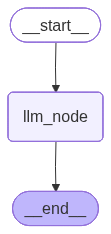

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [12]:
initial_state = {"question": "How far is the Moon from Earth?"}
final_state = workflow.invoke(initial_state)
print(final_state['question'])
print(final_state['answer'])

How far is the Moon from Earth?
The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point (called perigee), the Moon is about 356,400 kilometers (221,500 miles) away, and at its farthest point (apogee), it is about 405,500 kilometers (252,000 miles) away.
